# visual_compare2d interactive plotting

Use this notebook on an interactive compute node to tune figure layout frame by frame. It reuses `visual_compare2d.py`, so fixes in the script stay available here after `importlib.reload(vc)`.

In [35]:
%matplotlib inline

from pathlib import Path
from types import SimpleNamespace
import importlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

CODE_DIR = Path('/scratch/shujianjia/project/thesis/Thesis-Shujianjia/code')
os.chdir(CODE_DIR)
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import visual_compare2d as vc
vc = importlib.reload(vc)
plt.switch_backend('module://matplotlib_inline.backend_inline')

torch.set_grad_enabled(False)
print(f'Working directory: {Path.cwd()}')

Working directory: /scratch/shujianjia/project/thesis/Thesis-Shujianjia/code


## Configuration

Change checkpoint, scenes, frame number, or output directory here. Use `device='cuda'` on a GPU interactive node.

In [9]:
args = SimpleNamespace(
    checkpoint_path='checkpoints/run_20260621_180733/best_epoch_48_loss_0.0789.pth',
    output_dir='./results/visual_compare2d_notebook',
    dataset_path='/scratch/shujianjia/dataset/',
    train_val_scenes=[1, 3, 4, 5, 7],
    test_scenes=[6],
    model='CustomUNet2Layer',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    alpha=2.0,
    cfar_threshold=1.5,
    cfar_folder='radar_ososos',
    ignacio_folder='network2d_original',
)

print(args)

namespace(checkpoint_path='checkpoints/run_20260621_180733/best_epoch_48_loss_0.0789.pth', output_dir='./results/visual_compare2d_notebook', dataset_path='/scratch/shujianjia/dataset/', train_val_scenes=[1, 3, 4, 5, 7], test_scenes=[6], model='CustomUNet2Layer', device='cuda', alpha=2.0, cfar_threshold=1.5, cfar_folder='radar_ososos', ignacio_folder='network2d_original')


In [10]:
params = vc.build_params(args.dataset_path, args.train_val_scenes, args.test_scenes)
params['cfar_folder'] = args.cfar_folder

dataset = vc.RaDelftWrapper(mode='test', params=params)
x_grid, y_grid = vc.build_coordinate_grid(params)
model = vc.load_model(args)

frame_to_index = {}
for dataset_index, metadata in dataset.real_dataset.data_dict.items():
    scene, frame = vc.extract_scene_frame(metadata, dataset_index)
    frame_to_index[(scene, frame)] = dataset_index

print(f'Loaded {len(frame_to_index)} frames on device={args.device}')
print('First 10 keys:', list(frame_to_index.keys())[:10])
_frames_by_scene = {}
for _scene_id, _frame_id in frame_to_index:
    _frames_by_scene.setdefault(_scene_id, []).append(_frame_id)
for _scene_id, _frame_ids in sorted(_frames_by_scene.items()):
    _frame_ids = sorted(_frame_ids)
    print(f'Scene {_scene_id}: frame range {_frame_ids[0]}..{_frame_ids[-1]}, count={len(_frame_ids)}')

--------------------------------------------------
test dataset loaded with 2380 samples
scenes used: [6]
--------------------------------------------------


/home/shujianjia/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/shujianjia/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded 2380 frames on device=cuda
First 10 keys: [(6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9), (6, 10)]
Scene 6: frame range 1..2380, count=2380


In [36]:
def available_frames(scene=None):
    frames_by_scene = {}
    for scene_id, frame_id in frame_to_index:
        frames_by_scene.setdefault(scene_id, []).append(frame_id)
    for scene_id in frames_by_scene:
        frames_by_scene[scene_id] = sorted(frames_by_scene[scene_id])
    if scene is None:
        return frames_by_scene
    return frames_by_scene.get(scene, [])


def resolve_dataset_index(scene=6, frame=None, dataset_index=None):
    if dataset_index is not None:
        if dataset_index not in dataset.real_dataset.data_dict:
            valid = list(dataset.real_dataset.data_dict.keys())
            raise KeyError(f'dataset_index={dataset_index} not found. Valid index range: {min(valid)}..{max(valid)}')
        return dataset_index

    frames = available_frames(scene)
    if not frames:
        scenes = sorted(available_frames().keys())
        raise KeyError(f'Scene {scene} not found. Available scenes: {scenes}')

    if frame is None:
        frame = frames[0]

    key = (scene, frame)
    if key not in frame_to_index:
        nearest = sorted(frames, key=lambda value: abs(value - frame))[:8]
        raise KeyError(
            f'Frame {frame} not found in Scene {scene}. '
            f'Available range: {frames[0]}..{frames[-1]}, count={len(frames)}. '
            f'Nearest frames: {nearest}'
        )
    return frame_to_index[key]


def build_frame_data(scene=6, frame=None, dataset_index=None):
    dataset_index = resolve_dataset_index(scene=scene, frame=frame, dataset_index=dataset_index)
    sample = dataset[dataset_index]
    metadata = sample['metadata']
    scene, frame = vc.extract_scene_frame(metadata, dataset_index)

    radar_cube = sample['radar_cube'].unsqueeze(0).to(args.device)
    gt_np = sample['occupancy_target'].squeeze().cpu().numpy() > 0.5
    energy = vc.radar_energy_from_tensor(radar_cube)
    if gt_np.shape != energy.shape:
        raise ValueError(f'Shape mismatch: gt={gt_np.shape}, energy={energy.shape}')

    cfar = vc.cfar_mask(energy, args.cfar_threshold)
    proposed = vc.proposed_mask(model, radar_cube, args.alpha)

    gt_points = vc.points_from_mask(gt_np, x_grid, y_grid)
    cfar_points = vc.points_from_mask(cfar, x_grid, y_grid)
    proposed_points = vc.points_from_mask(proposed, x_grid, y_grid)
    ignacio_path, ignacio_points = vc.load_ignacio_points(metadata, args.ignacio_folder)

    return {
        'scene': scene,
        'frame': frame,
        'metadata': metadata,
        'x_grid': x_grid,
        'y_grid': y_grid,
        'energy': energy,
        'gt_points': gt_points,
        'cfar_points': cfar_points,
        'proposed_points': proposed_points,
        'ignacio_points': ignacio_points,
        'cfar_cd': vc.compute_chamfer_distance_2d(gt_points, cfar_points),
        'proposed_cd': vc.compute_chamfer_distance_2d(gt_points, proposed_points),
        'ignacio_cd': vc.compute_chamfer_distance_2d(gt_points, ignacio_points),
        'ignacio_path': str(ignacio_path),
    }


def show_frame(
    scene=6,
    frame=None,
    dataset_index=None,
    figsize=(22, 9),
    top_height=0.95,
    camera_aspect='auto',
    camera_title=True,
    colorbar_inside=True,
    save=False,
    display_inline=True,
    output_format='png',
    dpi=180,
):
    frame_data = build_frame_data(scene=scene, frame=frame, dataset_index=dataset_index)
    layout = [
        ['camera', 'camera', 'camera', 'radar_energy'],
        ['cfar_pred', 'Proposed method', 'Ignacionetwork', 'gt_pc'],
    ]
    fig, axd = plt.subplot_mosaic(
        layout,
        figsize=figsize,
        layout='constrained',
        gridspec_kw={'height_ratios': [top_height, 1.0]},
    )
    fig.suptitle(f"Scene {frame_data['scene']} | Frame {frame_data['frame']}", fontsize=24)

    axd['camera'].imshow(vc.camera_image(frame_data['metadata']), aspect=camera_aspect)
    if camera_title:
        axd['camera'].set_title('Camera Reference', fontsize=24)
    axd['camera'].axis('off')

    radar_energy_db = 10 * np.log10(frame_data['energy'] + 1e-9) + 39.54
    mesh = axd['radar_energy'].pcolormesh(
        -frame_data['x_grid'],
        frame_data['y_grid'],
        radar_energy_db,
        cmap='jet',
        shading='gouraud',
    )
    mesh.set_rasterized(True)
    axd['radar_energy'].set_title('Radar Energy (dB)', fontsize=24)
    vc.setup_point_axis(axd['radar_energy'], frame_data['x_grid'], frame_data['y_grid'])
    if colorbar_inside:
        cax = inset_axes(axd['radar_energy'], width='3%', height='62%', loc='center right', borderpad=1.0)
        cbar = fig.colorbar(mesh, cax=cax)
    else:
        cbar = fig.colorbar(mesh, ax=axd['radar_energy'], fraction=0.035, pad=0.05)
    cbar.ax.tick_params(labelsize=13)

    vc.plot_points(
        axd['cfar_pred'],
        frame_data['cfar_points'],
        'tab:purple',
        f"CA-CFAR, CD={vc.format_cd(frame_data['cfar_cd'])}",
        frame_data['x_grid'],
        frame_data['y_grid'],
    )
    vc.plot_points(
        axd['Proposed method'],
        frame_data['proposed_points'],
        'tab:red',
        f"Proposed method, CD={vc.format_cd(frame_data['proposed_cd'])}",
        frame_data['x_grid'],
        frame_data['y_grid'],
    )
    vc.plot_points(
        axd['Ignacionetwork'],
        frame_data['ignacio_points'],
        'tab:blue',
        f"DL baseline, CD={vc.format_cd(frame_data['ignacio_cd'])}",
        frame_data['x_grid'],
        frame_data['y_grid'],
    )
    vc.plot_points(
        axd['gt_pc'],
        frame_data['gt_points'],
        'tab:green',
        f"LiDAR GT (n={len(frame_data['gt_points'])})",
        frame_data['x_grid'],
        frame_data['y_grid'],
    )

    if save:
        output_dir = Path(args.output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        save_path = output_dir / f"scene_{frame_data['scene']}_frame_{frame_data['frame']}.{output_format}"
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', format=output_format)
        print(f'Saved: {save_path}')

    print({
        'scene': frame_data['scene'],
        'frame': frame_data['frame'],
        'cfar_cd': frame_data['cfar_cd'],
        'proposed_cd': frame_data['proposed_cd'],
        'ignacio_cd': frame_data['ignacio_cd'],
        'ignacio_path': frame_data['ignacio_path'],
    })
    if display_inline:
        display(fig)
    return fig, axd, frame_data

## Render one frame

Tune `top_height`, `camera_aspect`, `figsize`, and `colorbar_inside` here. Set `save=True` when the figure looks good.

{'scene': 6, 'frame': 1, 'cfar_cd': 3.4891341567988947, 'proposed_cd': 1.6515245988330944, 'ignacio_cd': 6.548809733488869, 'ignacio_path': '/scratch/shujianjia/dataset/Scene6/rosDS/network2d_original/001696858562.963005781.npy'}


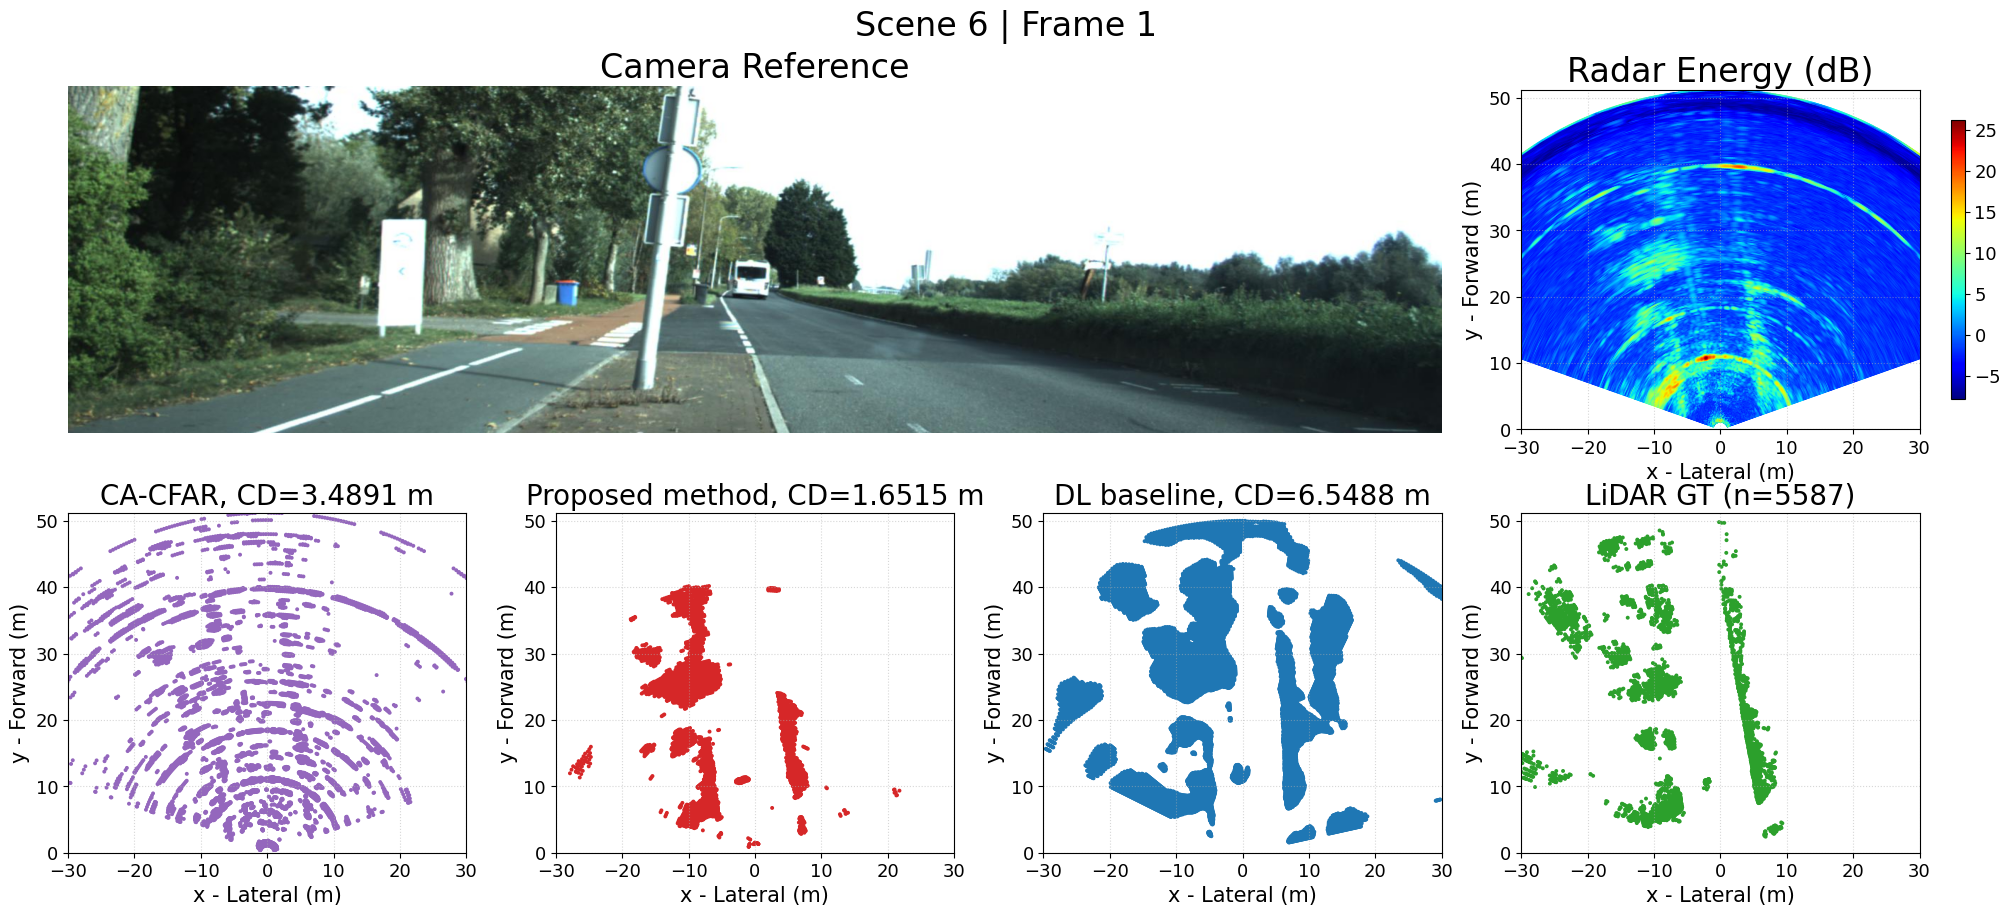

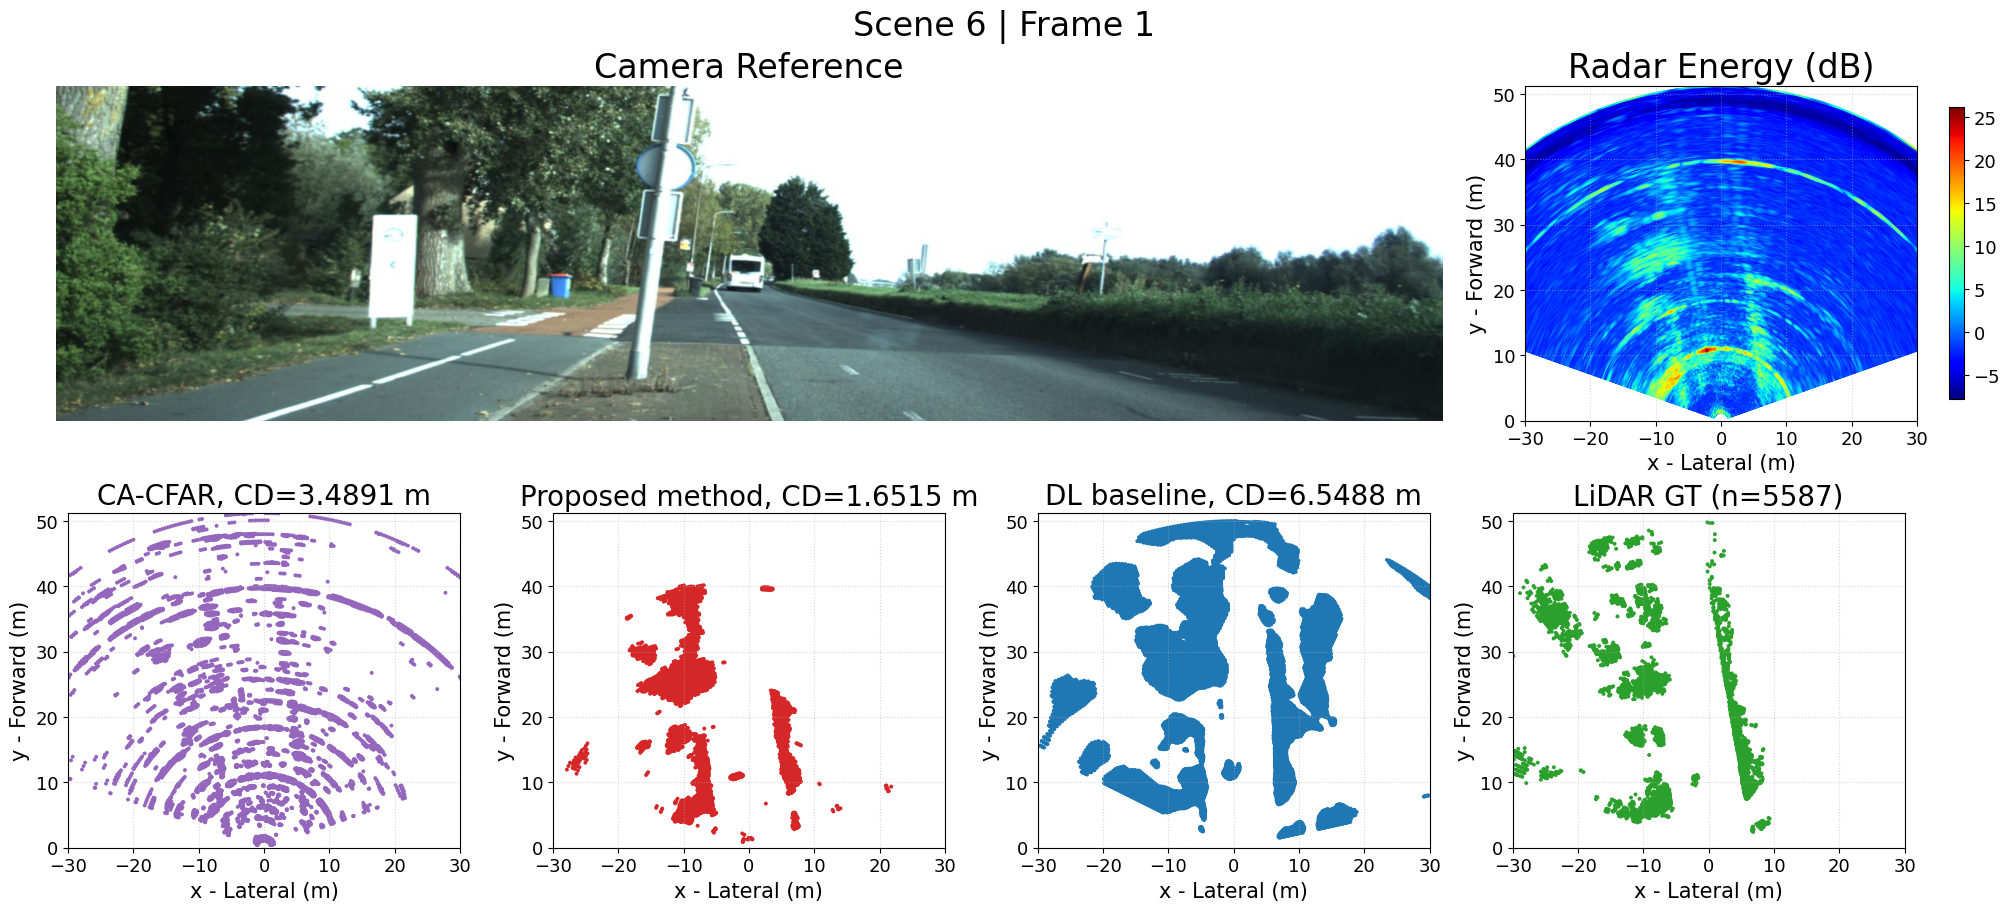

In [37]:
fig, axd, frame_data = show_frame(
    scene=6,
    frame=None,
    figsize=(20, 9),
    top_height=1,
    camera_aspect='auto',
    colorbar_inside=False,
    display_inline=True,
    save=False,
)


## Optional: widget slider

Run this cell if `ipywidgets` is available in the Jupyter environment.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    frame_slider = widgets.IntSlider(value=1, min=1, max=max(frame for _, frame in frame_to_index), step=1, description='Frame')
    top_height_slider = widgets.FloatSlider(value=0.95, min=0.65, max=1.25, step=0.05, description='Top h')

    def _interactive_plot(frame, top_height):
        plt.close('all')
        show_frame(scene=args.test_scenes[0], frame=frame, top_height=top_height, save=False)

    display(widgets.interactive(_interactive_plot, frame=frame_slider, top_height=top_height_slider))
except ImportError:
    print('ipywidgets is not installed in this environment. Use show_frame(...) manually instead.')

## Save the tuned frame

Use this after you settle on a layout.

In [ ]:
fig, axd, frame_data = show_frame(
    scene=6,
    frame=None,
    figsize=(22, 9),
    top_height=0.95,
    camera_aspect='auto',
    colorbar_inside=True,
    display_inline=True,
    save=True,
    output_format='png',
    dpi=220,
)
